# Extended Data Figure 8 — Target-disease translation success by pleiotropy

Phase-to-phase transition probabilities (P1→P2, P2→P3, P3→Approval) for drug
target-indication pairs stratified by gene pleiotropy level:

- **Low** (1 therapeutic area)
- **Medium** (2–5 therapeutic areas)
- **High** (≥ 6 therapeutic areas)

**Source notebook:** `chapters/02-analysis/06-target-enrichment/10-gps-in-clinical-stages.ipynb`  
**Data:** `data/intermediate_files/df_for_enrichment_regression.csv`


## Setup


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


## Paths


In [2]:
path_to_intermediate_data_folder = "../../../data/intermediate_files/"
regression_csv_path = path_to_intermediate_data_folder + "df_for_enrichment_regression.csv"


## Load enrichment regression data

This CSV contains one row per target-indication pair with genetic evidence,
including `uniqueTherapeuticAreas` (gene pleiotropy proxy) and `maxClinicalPhase`.


In [3]:
df = pd.read_csv(regression_csv_path)
print(f"Target-indication pairs: {len(df):,}")
print("Columns:", df.columns.tolist())
df.head()


Target-indication pairs: 37,377
Columns: ['targetId', 'diseaseId', 'indirect_assoc_score', 'max_beta', 'min_maf', 'max_vep', 'maxClinicalPhase', 'uniqueDiseases', 'uniqueTherapeuticAreas', 'outcome', 'geneticSupport']


,targetId,diseaseId,indirect_assoc_score,max_beta,min_maf,max_vep,maxClinicalPhase,uniqueDiseases,uniqueTherapeuticAreas,outcome,geneticSupport
0,ENSG00000004779,MONDO_0020121,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0,0
1,ENSG00000011677,EFO_0005411,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0,0
2,ENSG00000018625,EFO_0000544,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0
3,ENSG00000022355,EFO_0007634,0.0,0.0,0.0,0.0,2.0,1.0,1.0,0,0
4,ENSG00000053918,EFO_0000546,0.0,0.0,0.0,0.0,2.0,18.0,11.0,0,0


## Bin target-indication pairs by pleiotropy

Use `uniqueTherapeuticAreas` as a proxy for gene-level pleiotropy (gPS).


In [4]:
from statsmodels.stats.proportion import proportion_confint

df_phase = df.copy()
bins = [0, 1, 5, float("inf")]
labels = ["Low (1)", "Medium (2-5)", "High (6+)"]
df_phase["pleio_bin"] = pd.cut(df_phase["uniqueTherapeuticAreas"], bins=bins, labels=labels)
print(df_phase["pleio_bin"].value_counts().sort_index())


pleio_bin
Low (1)         6578
Medium (2-5)    9705
High (6+)       2197
Name: count, dtype: int64


## Compute phase transition probabilities


In [5]:
transitions = [(1, 2, "P1 -> P2"), (2, 3, "P2 -> P3"), (3, 4, "P3 -> P4")]
transition_results = []

for label in labels:
    subset = df_phase[df_phase["pleio_bin"] == label]
    for start_f, end_f, name in transitions:
        n_start = len(subset[subset["maxClinicalPhase"] >= start_f])
        n_end = len(subset[subset["maxClinicalPhase"] >= end_f])
        rate = n_end / n_start if n_start > 0 else 0
        ci_lo, ci_hi = proportion_confint(n_end, n_start, alpha=0.05, method="wilson") if n_start > 0 else (0, 0)
        transition_results.append(
            {
                "Pleiotropy": label,
                "Transition": name,
                "Success Rate": rate,
                "N_at_start": n_start,
                "ci_low": ci_lo,
                "ci_high": ci_hi,
            }
        )

trans_df = pd.DataFrame(transition_results)

# Table 1 — success rates
print("Success rates by transition and pleiotropy:")
print(trans_df.pivot(index="Transition", columns="Pleiotropy", values="Success Rate").round(3).to_string())


Success rates by transition and pleiotropy:
Pleiotropy  High (6+)  Low (1)  Medium (2-5)
Transition                                  
P1 -> P2        0.826    0.829         0.842
P2 -> P3        0.498    0.570         0.535
P3 -> P4        0.306    0.294         0.312


## Table 2 — Statistical tests (chi-square omnibus + pairwise z-tests)


In [6]:
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
import numpy as np

_stage_list = [
    (1, 2, "Phase 1 -> 2"),
    (2, 3, "Phase 2 -> 3"),
    (3, 4, "Phase 3 -> 4"),
]
_name_map = {
    "Phase 1 -> 2": "P1 -> P2",
    "Phase 2 -> 3": "P2 -> P3",
    "Phase 3 -> 4": "P3 -> P4",
}
_comp_names = ["med_vs_low", "high_vs_low", "high_vs_med"]

# ── Pass 1: raw stats per transition ──────────────────────────────────────────
raw = {}
for start_f, end_f, stage_name in _stage_list:
    grp = {}
    contingency = []
    for label in labels:
        subset = df_phase[df_phase["pleio_bin"] == label]
        n_in = len(subset[subset["maxClinicalPhase"] >= start_f])
        n_out = len(subset[subset["maxClinicalPhase"] >= end_f])
        n_fail = n_in - n_out
        grp[label] = {"n_in": n_in, "n_out": n_out, "n_fail": n_fail, "rate": (n_out / n_in * 100) if n_in > 0 else 0}
        contingency.append([n_out, n_fail])
    _, p_omni, _, _ = chi2_contingency(contingency)

    def _pw(a_lbl, b_lbl, g=grp):
        a, b = g[a_lbl], g[b_lbl]
        _, p_z = proportions_ztest([a["n_out"], b["n_out"]], [a["n_in"], b["n_in"]])
        rr = (a["n_out"] / a["n_in"]) / (b["n_out"] / b["n_in"])
        se = np.sqrt(a["n_fail"] / (a["n_out"] * a["n_in"]) + b["n_fail"] / (b["n_out"] * b["n_in"]))
        ci_lo = np.exp(np.log(rr) - 1.96 * se)
        ci_hi = np.exp(np.log(rr) + 1.96 * se)
        return p_z, rr, ci_lo, ci_hi

    raw[stage_name] = {
        "grp": grp,
        "p_omni": p_omni,
        "comps": {
            "med_vs_low": _pw("Medium (2-5)", "Low (1)"),
            "high_vs_low": _pw("High (6+)", "Low (1)"),
            "high_vs_med": _pw("High (6+)", "Medium (2-5)"),
        },
    }

# ── Pass 2: BH-FDR across all 9 pairwise p-values ─────────────────────────────
stage_names = [s for _, _, s in _stage_list]
_keys = [(sn, cn) for sn in stage_names for cn in _comp_names]
_praw = [raw[sn]["comps"][cn][0] for sn, cn in _keys]
_, _padj, _, _ = multipletests(_praw, method="fdr_bh")
_padj_map = {k: p for k, p in zip(_keys, _padj)}

# ── Pass 3: output table + pairwise_pvals for plot cell ───────────────────────
pairwise_pvals = {_name_map[sn]: {cn: _padj_map[(sn, cn)] for cn in _comp_names} for sn in stage_names}


def _fmt(rr, lo, hi):
    return f"{rr:.2f} ({lo:.2f}–{hi:.2f})"


table_rows = []
for sn in stage_names:
    grp = raw[sn]["grp"]
    comps = raw[sn]["comps"]
    row = {"Transition": sn}
    for lbl, short in [("Low (1)", "Low"), ("Medium (2-5)", "Medium"), ("High (6+)", "High")]:
        row[f"{short} (N)"] = grp[lbl]["n_in"]
        row[f"{short} %"] = f"{grp[lbl]['rate']:.1f}%"
    row["P (Omnibus)"] = f"{raw[sn]['p_omni']:.4f}"
    for cn, pair in [("med_vs_low", "Med vs Low"), ("high_vs_low", "High vs Low"), ("high_vs_med", "High vs Med")]:
        p_raw, rr, lo, hi = comps[cn]
        row[f"P_raw ({pair})"] = f"{p_raw:.4f}"
        row[f"P_adj ({pair})"] = f"{_padj_map[(sn, cn)]:.4f}"
        row[f"RR ({pair})"] = _fmt(rr, lo, hi)
    table_rows.append(row)

final_table = pd.DataFrame(table_rows)
print("SUMMARY ATTRITION TABLE — BH-FDR corrected pairwise p-values (9 tests)")
print("=" * 180)
print(final_table.to_string(index=False))
print("=" * 180)


SUMMARY ATTRITION TABLE — BH-FDR corrected pairwise p-values (9 tests)
  Transition  Low (N) Low %  Medium (N) Medium %  High (N) High % P (Omnibus) P_raw (Med vs Low) P_adj (Med vs Low)  RR (Med vs Low) P_raw (High vs Low) P_adj (High vs Low) RR (High vs Low) P_raw (High vs Med) P_adj (High vs Med) RR (High vs Med)
Phase 1 -> 2     6578 82.9%        9705    84.2%      2197  82.6%      0.0376             0.0257             0.0577 1.02 (1.00–1.03)              0.7592              0.7592 1.00 (0.97–1.02)              0.0650              0.1170 0.98 (0.96–1.00)
Phase 2 -> 3     5453 57.0%        8173    53.5%      1815  49.8%      0.0000             0.0001             0.0003 0.94 (0.91–0.97)              0.0000              0.0000 0.87 (0.83–0.92)              0.0034              0.0103 0.93 (0.88–0.98)
Phase 3 -> 4     3110 29.4%        4376    31.2%       903  30.6%      0.2384             0.0906             0.1359 1.06 (0.99–1.14)              0.4959              0.6376 1.04 (0.93–1.16

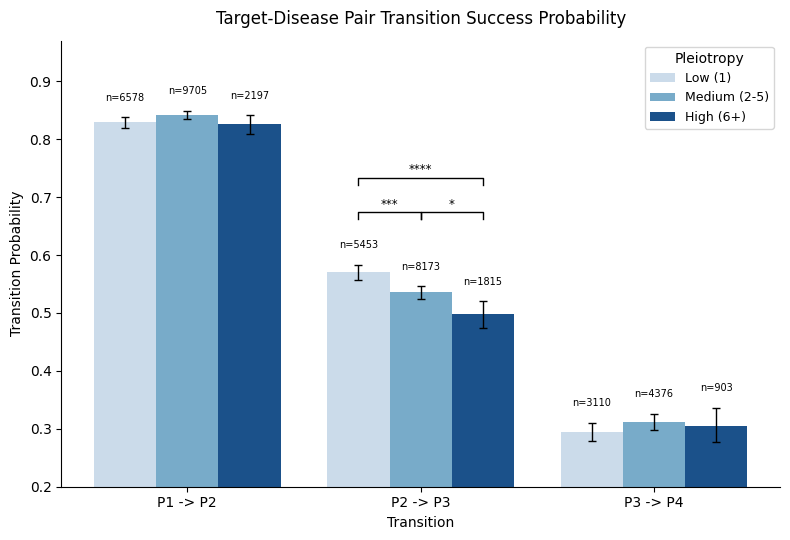

In [ ]:
def _p_to_stars(p):
    if p < 0.0001:
        return "****"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return None


def _sig_bracket(ax, x1, x2, y, label, tick_h=0.012, lw=1.0, fontsize=8.5):
    ax.plot([x1, x1, x2, x2], [y - tick_h, y, y, y - tick_h], lw=lw, color="black", clip_on=False)
    ax.text((x1 + x2) / 2, y + 0.003, label, ha="center", va="bottom", fontsize=fontsize, color="black")


fig, ax = plt.subplots(figsize=(8, 5.5))

palette = {"Low (1)": "#c6dbef", "Medium (2-5)": "#6baed6", "High (6+)": "#08519c"}

sns.barplot(
    data=trans_df,
    x="Transition",
    y="Success Rate",
    hue="Pleiotropy",
    order=[t[2] for t in transitions],
    hue_order=labels,
    palette=palette,
    ax=ax,
)

# Wilson 95% CI error bars + n= labels
for h_i, label in enumerate(labels):
    for t_i, (_, _, name) in enumerate(transitions):
        row = trans_df[(trans_df["Pleiotropy"] == label) & (trans_df["Transition"] == name)].iloc[0]
        bar = ax.containers[h_i].patches[t_i]
        x = bar.get_x() + bar.get_width() / 2.0
        y = row["Success Rate"]

        ax.errorbar(
            x=x,
            y=y,
            yerr=[[y - row["ci_low"]], [row["ci_high"] - y]],
            fmt="none",
            ecolor="black",
            elinewidth=1,
            capsize=3,
            zorder=10,
        )

        ax.text(x, row["ci_high"] + 0.025, f"n={int(row['N_at_start'])}", ha="center", va="bottom", fontsize=7)

# ── Significance brackets: P2→P3, FDR-corrected, three levels ─────────────────
x_low = ax.containers[0].patches[1].get_x() + ax.containers[0].patches[1].get_width() / 2
x_med = ax.containers[1].patches[1].get_x() + ax.containers[1].patches[1].get_width() / 2
x_high = ax.containers[2].patches[1].get_x() + ax.containers[2].patches[1].get_width() / 2

p2p3_ci_high = trans_df[trans_df["Transition"] == "P2 -> P3"]["ci_high"].max()
y_adj = p2p3_ci_high + 0.09  # adjacent brackets (Low-Med, Med-High)
y_span = y_adj + 0.06  # spanning bracket (Low-High) above the adjacent pair

p2p3 = pairwise_pvals.get("P2 -> P3", {})

stars_mvl = _p_to_stars(p2p3.get("med_vs_low", 1))
stars_hvm = _p_to_stars(p2p3.get("high_vs_med", 1))
stars_hvl = _p_to_stars(p2p3.get("high_vs_low", 1))

if stars_mvl:
    _sig_bracket(ax, x_low, x_med, y_adj, stars_mvl)
if stars_hvm:
    _sig_bracket(ax, x_med, x_high, y_adj, stars_hvm)
if stars_hvl:
    _sig_bracket(ax, x_low, x_high, y_span, stars_hvl)

ax.set_ylim(0.2, 0.97)
ax.set_ylabel("Transition Probability")
ax.set_xlabel("Transition")
ax.set_title("Target-Disease Pair Transition Success Probability", pad=12)
ax.legend(title="Pleiotropy", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig("extended_figure_8.pdf", dpi=300, bbox_inches="tight")
plt.show()
